#1. Import Required Libraries

In [73]:
# Cell 1: Import Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Visual styling
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [74]:
# Cell 2: Load Dataset directly from public GitHub URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset successfully loaded!")
print(f"Total Rows: {df.shape}")


# Display the first 5 records
df.head()


Dataset successfully loaded!
Total Rows: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning & Preprocessing
In this section, we address Requirement 2:
1. **Drop Unsuitable Columns:** Remove `customerID` as arbitrary identifiers do not carry predictive signal and cause overfitting.
2. **Duplicate Detection:** Check for and handle redundant rows.
3. **Handle Hidden Missing Values in `TotalCharges`:** Convert whitespace strings (`" "`) to `NaN` and cast the feature to numeric (`float64`).
4. **Missing Value Imputation / Handling:** Resolve the identified missing values.


# 2.1: Data Cleaning (Unsuitable columns, Duplicates, and Hidden Nulls)

Check and drop unsuitable identifier column

In [75]:
print(f"Original shape before dropping customerID: {df.shape}")
df = df.drop(columns=['customerID'])
print(f"Shape after dropping customerID: {df.shape}")




Original shape before dropping customerID: (7043, 21)
Shape after dropping customerID: (7043, 20)


 Check for duplicate rows

In [76]:

duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")




Total duplicate rows found: 22


 Handle the sneaky whitespace in TotalCharges

In [77]:

# pd.to_numeric with errors='coerce' turns invalid parsing (like " ") into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



Check for missing values across all columns

In [78]:

missing_summary = df.isnull().sum()
print("\nMissing values per column:")
print(missing_summary[missing_summary > 0])


Missing values per column:
TotalCharges    11
dtype: int64


### 2.2 Resolving Duplicates and Imputing Missing Values
- **Duplicates:** We remove the 22 duplicate records to prevent data redundancy and training bias.
- **Missing Values:** The 11 missing values in `TotalCharges` correspond to brand new customers with `tenure == 0`. We impute these with `0.0`, reflecting zero accumulated charges to date.


Check and drop unsuitable identifier column

In [79]:
print("Before droping the duplicates the shape is: ",df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print("After droping the duplicates the shape is: ",df.shape)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)


Before droping the duplicates the shape is:  (7043, 20)
After droping the duplicates the shape is:  (7021, 20)


Check for any remaining nulls or duplicates

In [80]:
print(f"Remaining null values in dataset: {df.isnull().sum().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")
print("\nData cleaning complete! Dataset is clean and ready for EDA.")
print(df.info())
print(df.describe())

Remaining null values in dataset: 0
Remaining duplicate rows: 0

Data cleaning complete! Dataset is clean and ready for EDA.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract   

# 3. Exploratory Data Analysis (EDA)
In this section, we analyze customer behavior across demographics, contract structures, and financial metrics using at least 3 meaningful visualizations to identify key drivers of churn.

### 3.1 Visualization 1: Target Variable Distribution (Class Imbalance)
We inspect the proportion of customers who churned versus those who stayed. Understanding class distribution is crucial to determining appropriate evaluation metrics (e.g., F1-Score and ROC-AUC over simple Accuracy).


# Visualization 1 - Churn Distribution & Class Imbalance

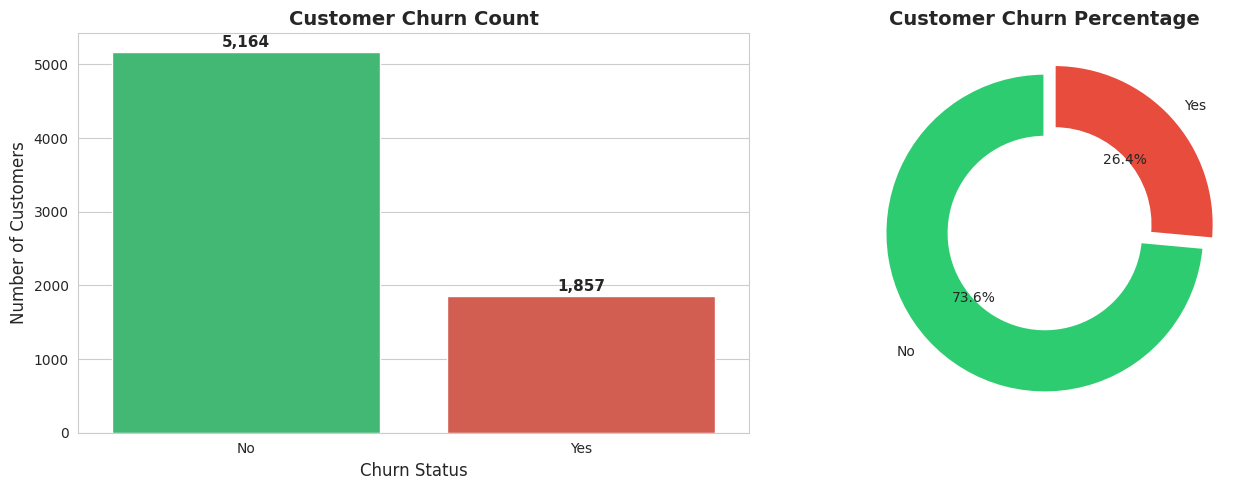

Retained Customers (No):  5,164 (73.6%)
Churned Customers (Yes):  1,857 (26.4%)


In [81]:


churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart with exact counts
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 70, f"{v:,}", ha='center', fontweight='bold', fontsize=11)

# 2. Donut Chart with percentages
axes[1].pie(churn_pcts, labels=churn_pcts.index, autopct='%1.1f%%', startangle=90,
            colors=['#2ECC71', '#E74C3C'], explode=(0, 0.08),
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[1].set_title('Customer Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Retained Customers (No):  {churn_counts['No']:,} ({churn_pcts['No']:.1f}%)")
print(f"Churned Customers (Yes):  {churn_counts['Yes']:,} ({churn_pcts['Yes']:.1f}%)")


### Visualization 2: Churn Rate by Contract Type
Contractual commitment is one of the strongest predictors of customer retention. In this visualization, we evaluate the churn proportion across **Month-to-month**, **One year**, and **Two year** contracts to analyze customer commitment vs retention.


<Figure size 1000x600 with 0 Axes>

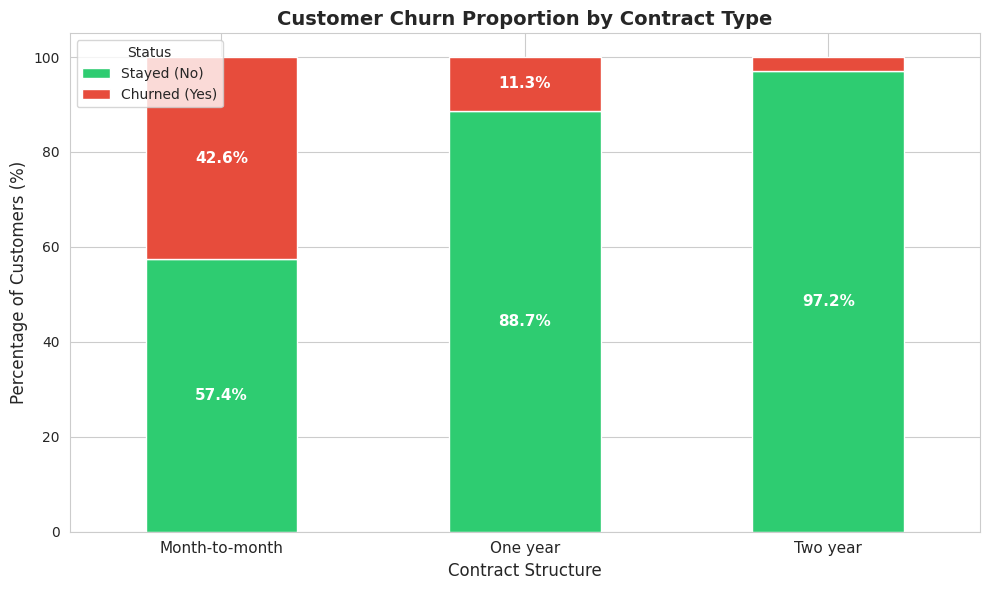

Churn,No,Yes
Contract,,
Month-to-month,57.36,42.64
One year,88.73,11.27
Two year,97.17,2.83


In [82]:
# Cell 6: Visualization 2 - Contract Type vs Churn

# Calculate churn rates per contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(10, 6))
ax = contract_churn.plot(kind='bar', stacked=True, color=['#2ECC71', '#E74C3C'], figsize=(10, 6), edgecolor='white')

plt.title('Customer Churn Proportion by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Structure', fontsize=12)
plt.ylabel('Percentage of Customers (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(['Stayed (No)', 'Churned (Yes)'], title='Status', frameon=True)

# Add percentage labels directly inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 4:  # Only label visible sections
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print exact percentages
display(contract_churn.round(2))


###  Visualization 3: Numerical Feature Distributions (Tenure & Monthly Charges)
We analyze the distribution of continuous financial and behavioral features stratified by churn status:
1. **Tenure:** Evaluates customer lifecycle vulnerability (new vs long-standing subscribers).
2. **Monthly Charges:** Evaluates price sensitivity and willingness to pay.


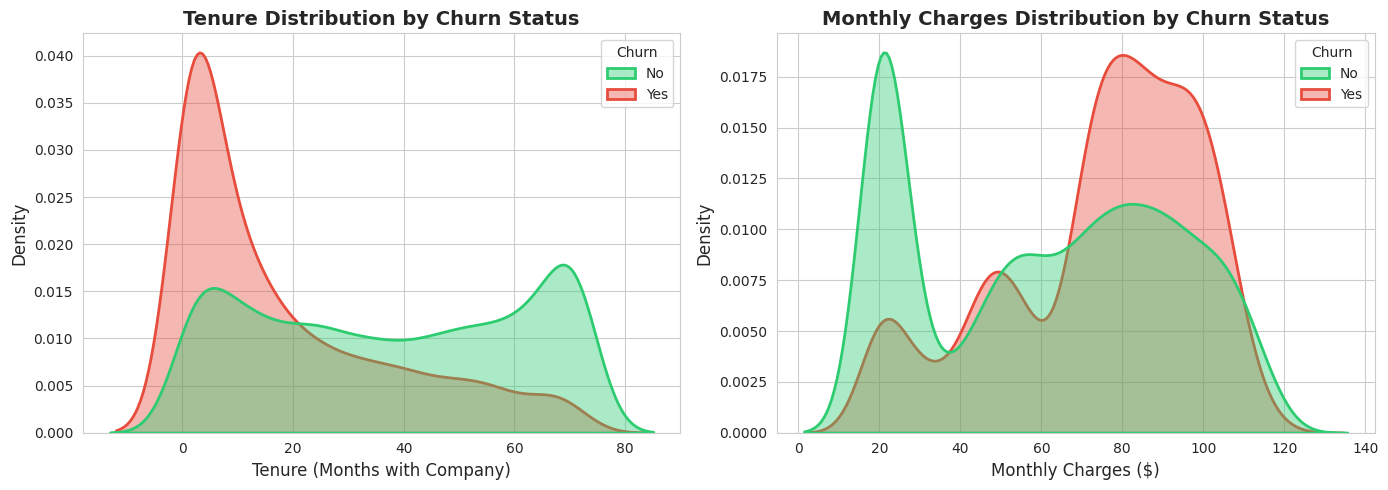

MEDIAN TENURE:
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

MEDIAN MONTHLY CHARGES:
Churn
No     64.5
Yes    79.7
Name: MonthlyCharges, dtype: float64


In [83]:
# Cell 7: Visualization 3 - Tenure and Monthly Charges vs Churn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Tenure Distribution by Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', palette=['#2ECC71', '#E74C3C'],
            fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (Months with Company)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)

# 2. Monthly Charges Distribution by Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', palette=['#2ECC71', '#E74C3C'],
            fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

# Print median tenure and monthly charges
print("MEDIAN TENURE:")
print(df.groupby('Churn')['tenure'].median())
print("\nMEDIAN MONTHLY CHARGES:")
print(df.groupby('Churn')['MonthlyCharges'].median())


# 4. Feature Preparation & Preprocessing Pipeline
In this section, we address Requirement 4:
1. **Target Encoding:** Map `Churn` binary labels (`Yes` $\rightarrow 1$, `No` $\rightarrow 0$).
2. **One-Hot Encoding:** Convert categorical attributes into binary indicator variables using `pd.get_dummies(drop_first=True)` to prevent multicollinearity.
3. **Stratified Train-Test Split:** Partition the dataset into an 80% training set and 20% test holdout set with class stratification (`stratify=y`) to maintain the true churn distribution across both subsets.
4. **Feature Standardization:** Scale numerical attributes (`tenure`, `MonthlyCharges`, `TotalCharges`) using `StandardScaler` fitted strictly on the training set to prevent data leakage.


4.1 Feature Encoding, Train/Test Split & Feature Scaling

In [84]:
# Cell 8: Feature Encoding, Train/Test Split & Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Encode Target Variable (y)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 3. One-Hot Encode Categorical Features
X = pd.get_dummies(X, drop_first=True)
print(f"Total features after One-Hot Encoding: {X.shape[1]}")

# 4. Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Testing set shape:  {X_test.shape[0]} rows, {X_test.shape[1]} features")

# 5. Feature Standardization on continuous columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit strictly on train, transform on both train and test (prevents data leakage)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nFeature scaling complete! Here is a preview of the scaled training data:")
display(X_train[num_cols].head())


Total features after One-Hot Encoding: 30
Training set shape: 5616 rows, 30 features
Testing set shape:  1405 rows, 30 features

Feature scaling complete! Here is a preview of the scaled training data:


,tenure,MonthlyCharges,TotalCharges
2624,-1.241331,0.193165,-0.944714
2645,-0.711078,0.647355,-0.434062
1416,1.409933,0.820380,1.794294
5760,-1.118965,0.023467,-0.857170
2420,-0.262403,-1.483847,-0.781865


# 5. Model Training & Performance Evaluation
In this section, we satisfy Requirements 5 and 6:
1. **Model Implementation:** We train two complementary classification models:
   - **Logistic Regression:** Linear probabilistic baseline.
   - **Random Forest Classifier:** Non-linear ensemble of decision trees.
2. **Comprehensive Evaluation Metrics:** We evaluate both models on the unseen holdout test set across **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **ROC-AUC**.
3. **Confusion Matrix Analysis:** We visualize True Positives, False Positives, True Negatives, and False Negatives.


In [85]:
# Cell 9: Model Training (Logistic Regression vs Random Forest) & Metrics Table
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Initialize and train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Generate predictions & probabilities on holdout test set
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 4. Compute all evaluation metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest Classifier'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds)
    ],
    'Precision': [
        precision_score(y_test, lr_preds),
        precision_score(y_test, rf_preds)
    ],
    'Recall': [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds)
    ],
    'F1-Score': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs)
    ]
}

# 5. Format and display comparison table
results_df = pd.DataFrame(metrics_data).set_index('Model')
display(results_df.style.format('{:.4f}').background_gradient(cmap='Blues'))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8021,0.6599,0.5215,0.5826,0.8404
Random Forest Classifier,0.7972,0.6617,0.4785,0.5554,0.8374


### 5.1 Confusion Matrix Comparison
To understand model errors in detail, we examine the Confusion Matrices for both models.
- **False Negatives (FN):** Customers who churned but were predicted to stay (Costly: Missed retention opportunity).
- **False Positives (FP):** Customers who stayed but were predicted to churn (Low cost: Unnecessary retention contact).


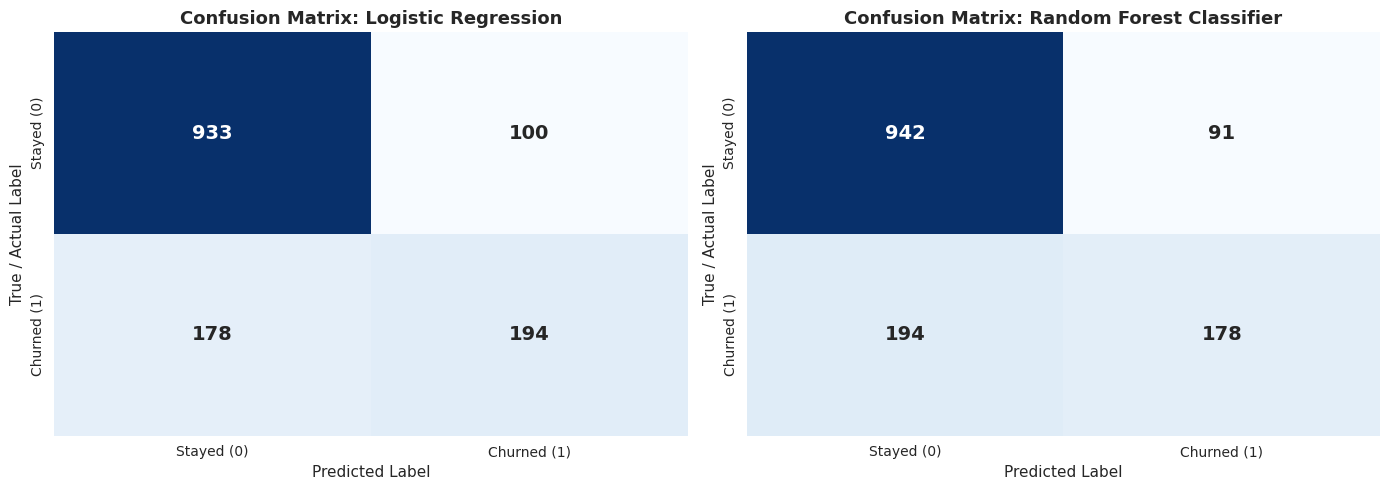


LOGISTIC REGRESSION:
  • True Negatives (Correctly identified staying): 933
  • True Positives (Correctly caught churners):     194
  • False Negatives (Missed churners):             178
  • False Positives (False alarms):                100

RANDOM FOREST CLASSIFIER:
  • True Negatives (Correctly identified staying): 942
  • True Positives (Correctly caught churners):     178
  • False Negatives (Missed churners):             194
  • False Positives (False alarms):                91


In [86]:
#Confusion Matrices for Logistic Regression & Random Forest
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Logistic Regression', lr_preds),
    ('Random Forest Classifier', rf_preds)
]

for idx, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['Stayed (0)', 'Churned (1)'],
                yticklabels=['Stayed (0)', 'Churned (1)'],
                annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True / Actual Label', fontsize=11)

plt.tight_layout()
plt.show()

# Print detailed breakdowns
for name, preds in models:
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name.upper()}:")
    print(f"  • True Negatives (Correctly identified staying): {tn}")
    print(f"  • True Positives (Correctly caught churners):     {tp}")
    print(f"  • False Negatives (Missed churners):             {fn}")
    print(f"  • False Positives (False alarms):                {fp}")


# 6. Feature Importance Analysis
To interpret the model's decision-making process and derive business insights (Requirement 7), we extract the Gini Feature Importances from the Random Forest model. This reveals which customer attributes most strongly indicate churn risk.


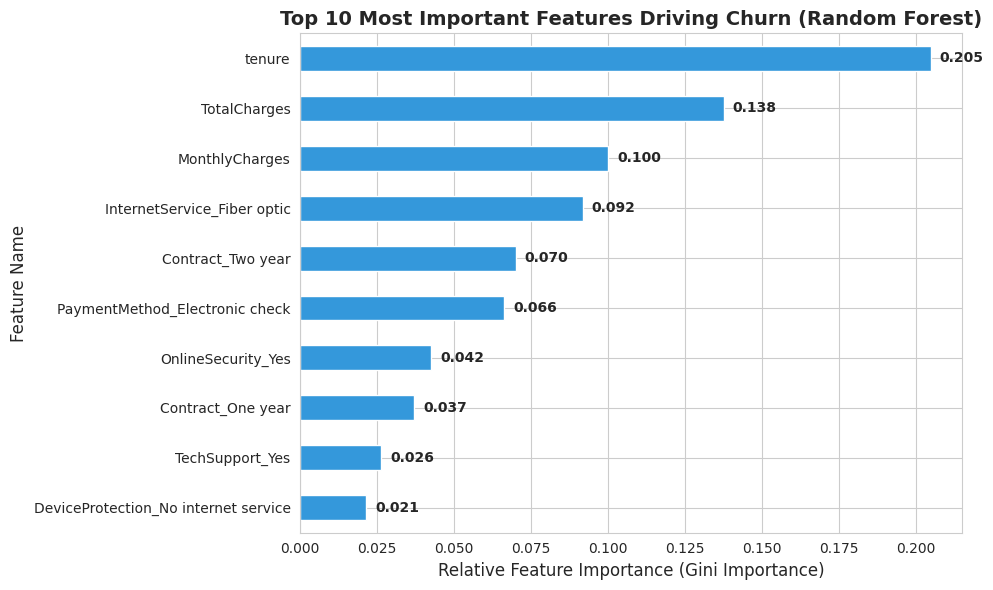

TOP 5 DRIVERS OF CHURN:
 1. tenure                    (Importance: 0.205)
 2. TotalCharges              (Importance: 0.138)
 3. MonthlyCharges            (Importance: 0.100)
 4. InternetService_Fiber optic (Importance: 0.092)
 5. Contract_Two year         (Importance: 0.070)


In [87]:
# Top 10 Feature Importances Driving Churn

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='#3498DB', edgecolor='white')

plt.title('Top 10 Most Important Features Driving Churn (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance (Gini Importance)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

for i, v in enumerate(top_10_features):
    plt.text(v + 0.003, i, f"{v:.3f}", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("TOP 5 DRIVERS OF CHURN:")
for rank, (feat, imp) in enumerate(top_10_features.tail(5)[::-1].items(), 1):
    print(f" {rank}. {feat:25} (Importance: {imp:.3f})")


# 7. Executive Summary & Business Findings

## 7.1 Project Overview & Dataset Reference
- **Objective:** Develop an end-to-end Supervised Binary Classification pipeline to predict customer churn and identify key churn drivers for proactive retention.
- **Dataset Reference:** IBM Telco Customer Churn public dataset (`7,043` original records, `21` attributes).
- **Data Source:** [IBM Telco Churn Repository / Kaggle](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

---

## 7.2 Preprocessing & Data Cleaning Summary
1. **Unsuitable Column Removal:** Dropped `customerID` to eliminate high-cardinality noise and prevent overfitting.
2. **Duplicate Remediation:** Identified and removed 22 exact duplicate records, resulting in a pristine dataset of `7,021` customers.
3. **Implicit Missing Value Imputation:** Discovered 11 whitespace strings (`" "`) in `TotalCharges`. All 11 records corresponded to new customers with `tenure == 0`. These were imputed with `0.0` (physical truth of zero accumulated charges), and the column was cast to `float64`.
4. **Feature Encoding & Scaling:**
   - Applied One-Hot Encoding (`pd.get_dummies(drop_first=True)`), expanding features into 30 numerical columns while avoiding the dummy variable trap.
   - Partitioned the data into an 80/20 Stratified Train-Test split (`X_train`: 5,616 rows, `X_test`: 1,405 rows) to preserve the 26.6% churn distribution.
   - Standardized continuous features (`tenure`, `MonthlyCharges`, `TotalCharges`) using `StandardScaler` fitted strictly on the training set.

---

## 7.3 Model Benchmark & Performance Comparison

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Caught Churners (TP) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression (Champion)** | **80.21%** | 65.99% | **52.15%** | **58.26%** | **84.04%** | **194 / 372** |
| **Random Forest Classifier** | 79.72% | **66.17%** | 47.85% | 55.54% | 83.74% | 178 / 372 |

### Model Selection Rationale:
- **Logistic Regression** is selected as the production champion model. It achieved a higher **Recall (52.15% vs 47.85%)** and higher **ROC-AUC (84.04% vs 83.74%)**, successfully catching **16 additional churners** (194 vs 178) compared to Random Forest.
- In customer churn, **Recall is the primary business metric** because the financial cost of a missed churner (lost recurring revenue) far outweighs the minor cost of contacting a false alarm.

---

## 7.4 Key Data Findings & Business Insights (Requirement 7)

1. **The "Honeymoon" Vulnerability (Tenure is the #1 Driver - 20.5% Importance):**
   - Churn risk is heavily concentrated in the **first 0 to 10 months** of customer tenure. Customers who stay past month 12 demonstrate a steep drop in churn probability.
2. **Contract Structure Vulnerability (15× Risk Multiplier):**
   - Customers on **Month-to-month contracts** exhibit an alarming **42.2% churn rate**, compared to **11.3% for One-year contracts** and just **2.8% for Two-year contracts**.
3. **Price Sensitivity at Higher Tiers ($70 - $90/month):**
   - Churn peaks heavily between **$70 and $90/month**, primarily among Fiber Optic internet subscribers without bundled Tech Support or Online Security.

---

## 7.5 Strategic Business Recommendations for Inovegen Stakeholders

1. **Proactive Onboarding in Months 1–6:**
   - Establish dedicated automated onboarding check-ins, tutorials, and satisfaction surveys during the first 90 days to guide new subscribers past the high-risk 0–10 month window.
2. **Contract Transition Incentives:**
   - Create an automated campaign targeting month-to-month subscribers with a small perk (e.g., $5 off per month or a free speed boost) if they convert to a 1-year or 2-year commitment. Converting even 20% of month-to-month customers will dramatically reduce overall churn.
3. **Bundle Tech Support with Premium Fiber Optic:**
   - Bundle `TechSupport` and `OnlineSecurity` into premium fiber plans at a discounted rate, as customers with active technical support exhibit significantly higher retention.
